In [1]:
#библиотечки и т.д.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV

In [2]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
pd.options.display.float_format = '{:.2f}'.format
stats = pd.DataFrame({
    'Minimum': df.min(numeric_only=True),
    'Maximum': df.max(numeric_only=True),
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0]
})
print(stats)

               Minimum  Maximum  Mean  Median  Mode
Id                1.00   150.00 75.50   75.50  1.00
SepalLengthCm     4.30     7.90  5.84    5.80  5.00
SepalWidthCm      2.00     4.40  3.05    3.00  3.00
PetalLengthCm     1.00     6.90  3.76    4.35  1.50
PetalWidthCm      0.10     2.50  1.20    1.30  0.20


In [7]:
print("Количество экземпляров каждого вида:\n", df['Species'].value_counts())
#распределение видов равное (по методу зоркого глаза)

Количество экземпляров каждого вида:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [8]:
#кодирование
label_encoder = LabelEncoder()
df['Species'] = label_encoder.fit_transform(df['Species'])
print("закодированные метки классов:\n", df['Species'].unique())

закодированные метки классов:
 [0 1 2]


In [9]:
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [10]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.00,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20,1.00
std,43.45,0.83,0.43,1.76,0.76,0.82
min,1.00,4.30,2.00,1.00,0.10,0.00
25%,38.25,5.10,2.80,1.60,0.30,0.00
50%,75.50,5.80,3.00,4.35,1.30,1.00
75%,112.75,6.40,3.30,5.10,1.80,2.00
max,150.00,7.90,4.40,6.90,2.50,2.00


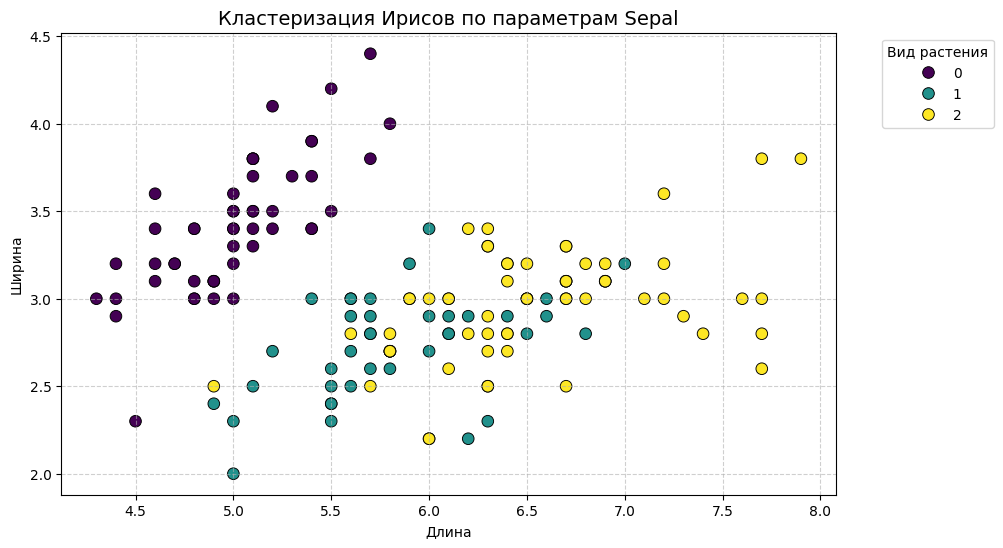

In [11]:
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(data=df, 
                          x='SepalLengthCm', 
                          y='SepalWidthCm',  
                          hue='Species',
                          palette='viridis', 
                          s=70, 
                          edgecolor='black',
                          alpha=1)

plt.title('Кластеризация Ирисов по параметрам Sepal', fontsize=14)
plt.xlabel('Длина')
plt.ylabel('Ширина')
plt.legend(title='Вид растения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

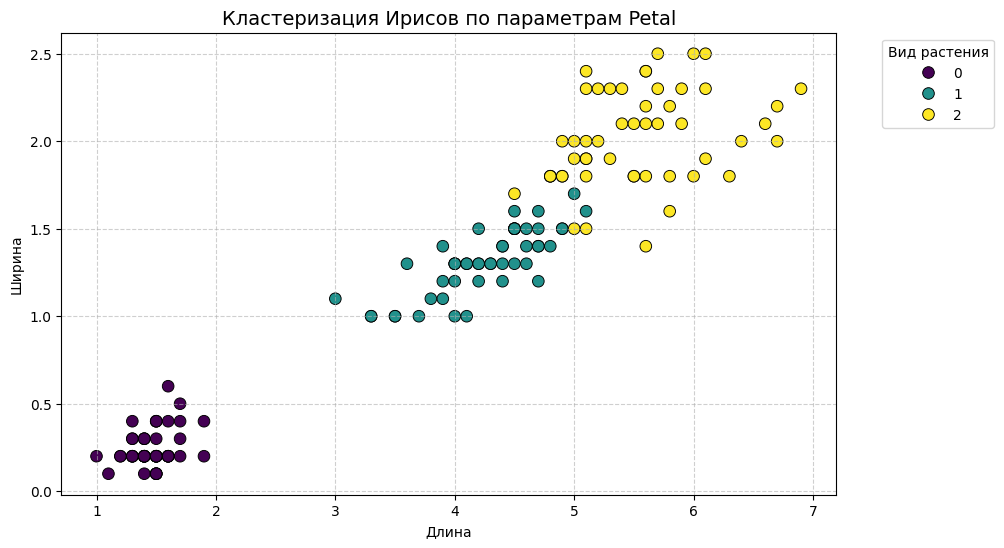

In [12]:
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(data=df, 
                          x='PetalLengthCm', 
                          y='PetalWidthCm',  
                          hue='Species',
                          palette='viridis', 
                          s=70, 
                          edgecolor='black',
                          alpha=1)

plt.title('Кластеризация Ирисов по параметрам Petal', fontsize=14)
plt.xlabel('Длина')
plt.ylabel('Ширина')
plt.legend(title='Вид растения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [13]:
y = df['Species']
df = df.drop(['Id', 'Species'], axis=1)

In [14]:
#кросс-валидация для оценки модели без масштабирования (спойлеры)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.5, random_state=42) 

# Определяем "сетку" параметров, которые хотим проверить
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Создаем объект поиска по сетке параметров
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

# Запускаем поиск лучших параметров на тренировочных данных
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность на кросс-валидации:", grid_search.best_score_)

# Проверяем лучшую модель на тестовых данных
best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print(f"Точность лучшей модели на тесте: {test_acc:.4f}")

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Лучшая точность на кросс-валидации: 0.9333333333333333
Точность лучшей модели на тесте: 0.9600


In [15]:
#масштабирование
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
X = df_scaled
X.describe()
#нужно для того чтобы все столбцы учитывались в одинаковой степени

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,0.43,0.44,0.47,0.46
std,0.23,0.18,0.30,0.32
min,0.00,0.00,0.00,0.00
25%,0.22,0.33,0.10,0.08
50%,0.42,0.42,0.57,0.50
75%,0.58,0.54,0.69,0.71
max,1.00,1.00,1.00,1.00


In [16]:
#разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 
#достаточно большая выборка для теста - модель работает хорошо, но все же проверке на одном наборе нельзя полностью доверять

#обучение моделей
neighbours = [1, 3, 5, 7, 10]
weights = ['uniform', 'distance']
metrics = ['euclidean', 'manhattan', 'minkowski']
knn_models = np.empty((len(neighbours), len(weights), len(metrics)), dtype=object)
result_accuracy = np.zeros((len(neighbours), len(weights), len(metrics)))

for i, n in enumerate(neighbours):
    for j, w in enumerate(weights):
        for k, m in enumerate(metrics):
            knn = KNeighborsClassifier(n_neighbors=n, weights=w, metric=m)
            knn.fit(X_train, y_train)
            knn_models[i, j, k] = knn
            score = knn.score(X_test, y_test)
            result_accuracy[i][j][k] = score
            print(f"Neighbours: {n}, Weights: {w}, Metric: {m}, Accuracy: {score:.4f}")

Neighbours: 1, Weights: uniform, Metric: euclidean, Accuracy: 1.0000
Neighbours: 1, Weights: uniform, Metric: manhattan, Accuracy: 0.9778
Neighbours: 1, Weights: uniform, Metric: minkowski, Accuracy: 1.0000
Neighbours: 1, Weights: distance, Metric: euclidean, Accuracy: 1.0000
Neighbours: 1, Weights: distance, Metric: manhattan, Accuracy: 0.9778
Neighbours: 1, Weights: distance, Metric: minkowski, Accuracy: 1.0000
Neighbours: 3, Weights: uniform, Metric: euclidean, Accuracy: 1.0000
Neighbours: 3, Weights: uniform, Metric: manhattan, Accuracy: 1.0000
Neighbours: 3, Weights: uniform, Metric: minkowski, Accuracy: 1.0000
Neighbours: 3, Weights: distance, Metric: euclidean, Accuracy: 1.0000
Neighbours: 3, Weights: distance, Metric: manhattan, Accuracy: 1.0000
Neighbours: 3, Weights: distance, Metric: minkowski, Accuracy: 1.0000
Neighbours: 5, Weights: uniform, Metric: euclidean, Accuracy: 1.0000
Neighbours: 5, Weights: uniform, Metric: manhattan, Accuracy: 1.0000
Neighbours: 5, Weights: unif

In [17]:
#разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=42) 
#выборка всего 10% (15 цветов) - результаты хуже, особенно для метрики uniform, 
#а distance работает лучше, так как учитывает расстояние до соседей, что полезно при малом количестве данных

#обучение моделей
neighbours = [1, 3, 5, 7, 10]
weights = ['uniform', 'distance']
metrics = ['euclidean', 'manhattan', 'minkowski']
knn_models = np.empty((len(neighbours), len(weights), len(metrics)), dtype=object)
result_accuracy = np.zeros((len(neighbours), len(weights), len(metrics)))

for i, n in enumerate(neighbours):
    for j, w in enumerate(weights):
        for k, m in enumerate(metrics):
            knn = KNeighborsClassifier(n_neighbors=n, weights=w, metric=m)
            knn.fit(X_train, y_train)
            knn_models[i, j, k] = knn
            score = knn.score(X_test, y_test)
            result_accuracy[i][j][k] = score
            print(f"Neighbours: {n}, Weights: {w}, Metric: {m}, Accuracy: {score:.4f}")

Neighbours: 1, Weights: uniform, Metric: euclidean, Accuracy: 0.9630
Neighbours: 1, Weights: uniform, Metric: manhattan, Accuracy: 0.9630
Neighbours: 1, Weights: uniform, Metric: minkowski, Accuracy: 0.9630
Neighbours: 1, Weights: distance, Metric: euclidean, Accuracy: 0.9630
Neighbours: 1, Weights: distance, Metric: manhattan, Accuracy: 0.9630
Neighbours: 1, Weights: distance, Metric: minkowski, Accuracy: 0.9630
Neighbours: 3, Weights: uniform, Metric: euclidean, Accuracy: 0.9407
Neighbours: 3, Weights: uniform, Metric: manhattan, Accuracy: 0.9481
Neighbours: 3, Weights: uniform, Metric: minkowski, Accuracy: 0.9407
Neighbours: 3, Weights: distance, Metric: euclidean, Accuracy: 0.9407
Neighbours: 3, Weights: distance, Metric: manhattan, Accuracy: 0.9481
Neighbours: 3, Weights: distance, Metric: minkowski, Accuracy: 0.9407
Neighbours: 5, Weights: uniform, Metric: euclidean, Accuracy: 0.6074
Neighbours: 5, Weights: uniform, Metric: manhattan, Accuracy: 0.5852
Neighbours: 5, Weights: unif

In [18]:
# Создаем модель
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')

# Автоматически обучаем и тестируем модель 5 раз на разных кусках данных
# cv=5 означает 5 итераций
scores = cross_val_score(knn, df, y, cv=5)

print(f"Точность на каждой итерации: {scores}")
print(f"Средняя точность модели: {scores.mean():.4f}")

Точность на каждой итерации: [0.96666667 1.         0.96666667 0.96666667 1.        ]
Средняя точность модели: 0.9800


In [19]:
#кросс-валидация, чтобы оценить стабильность модели на разных разбиениях данных, а не только на одном тестовом наборе
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42) 

# Определяем "сетку" параметров, которые хотим проверить
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Создаем объект поиска по сетке параметров
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

# Запускаем поиск лучших параметров на тренировочных данных
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность на кросс-валидации:", grid_search.best_score_)

# Проверяем лучшую модель на тестовых данных
best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print(f"Точность лучшей модели на тесте: {test_acc:.4f}")

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Лучшая точность на кросс-валидации: 0.9200000000000002
Точность лучшей модели на тесте: 0.9867


Выводы...
1) масштабирование - очень важный этап, но на нашем датасете он не сыграл особую роль, так как разброс значений по разным параметрам не очень большой
2) проверка на тестовых наборах - точность в среднем повышается с увеличением числа элементов в тренировочной выборке (еще влияет выбор метрики для расстояния - uniform особенно хуже на малых объемах данных)
3) кросс-валидация - результатам на 1 наборе доверять нельзя, так как они зависят от нашего random_state и статичны при каждом выборе этого параметра
4) итоговые данные для лучшей модели:
Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Лучшая точность на кросс-валидации: 0.9200000000000002
Точность лучшей модели на тесте: 0.9867